## Setup - Environment and data

In [1]:
import numpy as np
import pandas as pd 
from sklearn.datasets import fetch_openml #Just getting data.

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)
  
print(X.shape, y.shape)



(70000, 784) (70000,)


## Preprocess and split data

In [2]:
# Đặt seed để tái lập kết quả
np.random.seed(42)

n_samples = X.shape[0]
n_test = 1000

# Tạo mảng chỉ số rồi xáo trộn ngẫu nhiên
indices = np.arange(n_samples)
np.random.shuffle(indices)

# Cắt 1000 chỉ số đầu làm test, phần còn lại làm train
test_idx = indices[:n_test]
train_idx = indices[n_test:]

X_test, y_test = X[test_idx], y[test_idx]
X_train, y_train = X[train_idx], y[train_idx]

X_train = X_train.T
X_test = X_test.T
y_train = y_train.T
y_test = y_test.T

X_train = X_train / 255.0
X_test = X_test / 255.0

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (784, 69000) (69000,)
Test: (784, 1000) (1000,)


## Define helper

In [13]:
def ReLU(x: np.ndarray)->np.ndarray:
    return np.maximum(0, x)

def ReLU_derivative(x: int)->bool:
    return x>0
def softmax(x: np.ndarray) -> np.ndarray:
    x_max = np.max(x, axis=0, keepdims=True)
    e = np.exp(x - x_max)
    return e / np.sum(e, axis=0, keepdims=True)
def one_hot_encode(y:np.ndarray)->np.ndarray:
    y_encode = np.zeros([y.size, y.max() + 1])
    y_encode[np.arange(y.size),y] = 1
    y_encode = y_encode.T
    return y_encode

def get_pred (output_layer: np.ndarray):
    return np.argmax(output_layer, axis=0)
def get_accuracy(predictions, Y):
    return np.sum(predictions == Y) / Y.size

## Step by step to create Neural Network from scratch

In [ ]:
# Step 1: Matrix Setup & Parameter Initialization
def initialize_param(
        n_neuron_input: int,
        n_neuron_layer1: int,
        n_neuron_output: int
)->tuple[np.ndarray,np.ndarray,np.ndarray,np.ndarray]:
    W1 = np.random.rand(n_neuron_layer1,n_neuron_input)-0.5
    b1 = np.random.rand(n_neuron_layer1,1) -0.5
    W2 = np.random.rand(n_neuron_output,n_neuron_layer1) -0.5
    b2 = np.random.rand(n_neuron_output,1) -0.5

    return W1, b1, W2, b2

# Step 2: Forward Propagation
def forward_prop(
        X_train: np.ndarray,
        W1: np.ndarray,
        b1: np.ndarray,
        W2: np.ndarray,
        b2: np.ndarray
)->tuple[np.ndarray,np.ndarray,np.ndarray,np.ndarray]:
    Z1 = W1.dot(X_train) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)

    return Z1,A1,Z2,A2

# Step 3: Backward Propagation
def backward_prop(
        X_train: np.ndarray,
        y_train: np.ndarray,
        Z1: np.ndarray,
        Z2: np.ndarray,
        A1: np.ndarray,
        A2: np.ndarray,
        W1: np.ndarray,
        W2: np.ndarray

)->tuple[np.ndarray,np.ndarray,np.ndarray,np.ndarray]:
    onehot_y = one_hot_encode(y_train)
    m = y_train.shape[0] #số lượng mẫu
    dZ2 = A2 - onehot_y #deriative of loss function

    dW2 = (1/m)*dZ2.dot(A1.T)
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)

    dZ1 = (W2.T).dot(dZ2)*ReLU_derivative(Z1) #dấu nhân Lấy từng ô của ma trận 
    #kết quả trước nhân trực tiếp với đúng ô ở vị trí tương ứng của ma trận đạo hàm ReLU.

    dW1 = (1/m)*dZ1.dot(X_train.T)
    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)

    return dW2,db2,dW1,db1

# Step 4: Parameter Updates
def update_param(
    W1: np.ndarray,
    W2: np.ndarray,
    b1: np.ndarray,
    b2: np.ndarray,
    dW1,dW2,db1,db2,
    learning_rate
)->tuple[np.ndarray,np.ndarray,np.ndarray,np.ndarray]:
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1    
    W2 = W2 - learning_rate * dW2  
    b2 = b2 - learning_rate * db2    
    return W1, b1, W2, b2

## Core Execution Loop

In [ ]:
def main_loop(
        X_train: np.ndarray,
        y_train: np.ndarray,
        learning_rate: float = 0.1,
        iter: int = 1000
)->tuple[np.ndarray,np.ndarray,np.ndarray,np.ndarray]:
    W1,b1,W2,b2 = initialize_param(X_train.shape[0],16,10)
    #The training process
    for i in range(iter):
        Z1,A1,Z2,A2 = forward_prop(X_train,W1,b1,W2,b2)
        dW2,db2,dW1,db1 = backward_prop(X_train,y_train,Z1,Z2,A1,A2,W1,W2)
        W1,b1,W2,b2 = update_param(W1,W2,b1,b2,dW1,dW2,db1,db2,learning_rate)

        if i % 10 == 0: # in ra kết quả mỗi 10 vòng lặp
            print("Iteration: ", i)
            predictions = get_pred(A2)
            print(get_accuracy(predictions, y_train))

    return W1, b1, W2, b2




In [15]:
W1, b1, W2, b2 = main_loop(X_train,y_train,0.1,2000)

Iteration:  0
0.13342028985507245
Iteration:  10
0.25423188405797104
Iteration:  20
0.3240144927536232
Iteration:  30
0.3949130434782609
Iteration:  40
0.4617971014492754
Iteration:  50
0.5224927536231884
Iteration:  60
0.5728840579710145
Iteration:  70
0.6127536231884058
Iteration:  80
0.6454057971014493
Iteration:  90
0.6711449275362319
Iteration:  100
0.6927971014492753
Iteration:  110
0.7108695652173913
Iteration:  120
0.7265217391304348
Iteration:  130
0.7383623188405797
Iteration:  140
0.7487391304347826
Iteration:  150
0.7581159420289855
Iteration:  160
0.7659565217391304
Iteration:  170
0.7731739130434783
Iteration:  180
0.7798985507246377
Iteration:  190
0.7861304347826087
Iteration:  200
0.7912463768115942
Iteration:  210
0.7958260869565218
Iteration:  220
0.8005797101449276
Iteration:  230
0.8047101449275362
Iteration:  240
0.809
Iteration:  250
0.8129420289855073
Iteration:  260
0.8162898550724638
Iteration:  270
0.8196811594202899
Iteration:  280
0.8223623188405798
Iterati

## Visualization

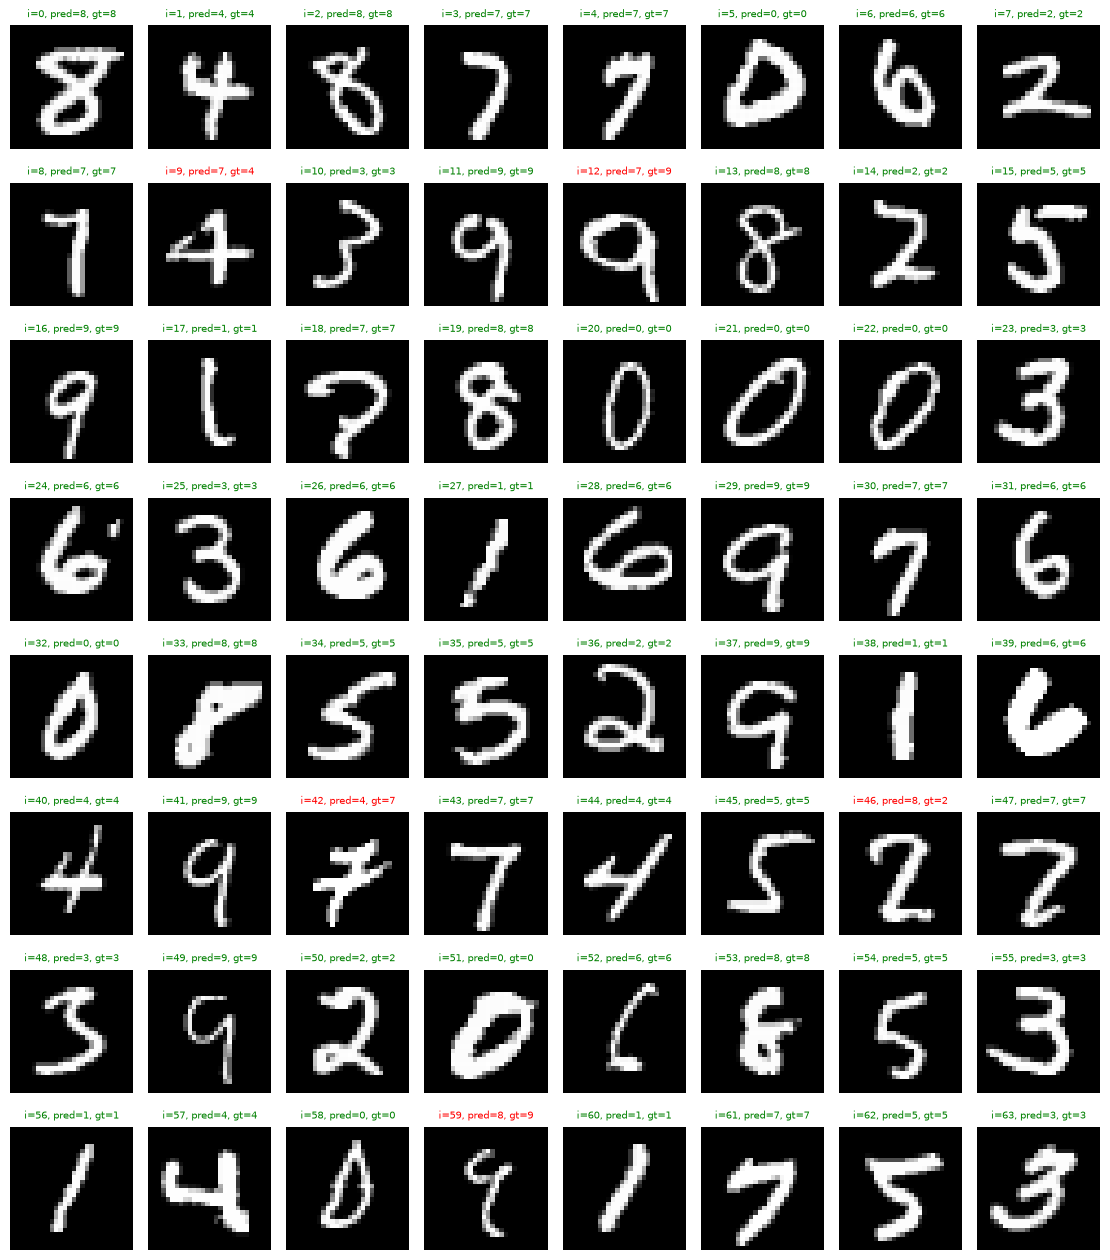

Accuracy trên y_test(1000 mẫu): 0.9150


In [17]:
import matplotlib.pyplot as plt

def predict(X, W1, b1, W2, b2):
    """Dự đoán label cho tập X (đã ở dạng features x samples, đã chuẩn hóa)."""
    _, _, _, A2 = forward_prop(X, W1, b1, W2, b2)
    return get_pred(A2)

def show_predictions(X_test, y_test, W1, b1, W2, b2, n_samples=64, n_cols=8, random_sample=False, seed=0):
    """
    X_test: shape (784, n_test), đã chuẩn hóa [0,1]
    y_test: shape (n_test,)
    """
    n_test = X_test.shape[1]
    n_samples = min(n_samples, n_test)

    if random_sample:
        rng = np.random.default_rng(seed)
        idx = rng.choice(n_test, size=n_samples, replace=False)
    else:
        idx = np.arange(n_samples)

    X_sub = X_test[:, idx]
    y_sub = y_test[idx]
    preds = predict(X_sub, W1, b1, W2, b2)

    n_rows = int(np.ceil(n_samples / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.4, n_rows * 1.6))
    axes = axes.flatten()

    for j in range(n_samples):
        ax = axes[j]
        img = X_sub[:, j].reshape(28, 28)
        ax.imshow(img, cmap='gray')
        ax.axis('off')

        pred = preds[j]
        gt = y_sub[j]
        correct = pred == gt
        color = 'green' if correct else 'red'

        ax.set_title(f"i={idx[j]}, pred={pred}, gt={gt}",
                     fontsize=7, color=color)

    # ẩn các ô thừa nếu n_samples không chia hết cho n_cols
    for j in range(n_samples, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


# Cách dùng:
show_predictions(X_test, y_test, W1, b1, W2, b2, n_samples=64, n_cols=8)

pred = predict(X_test,W1, b1, W2, b2)
acc_test = get_accuracy(pred, y_test)
print(f"Accuracy trên y_test(1000 mẫu): {acc_test:.4f}")
